# Final Project: Building and Stress-Testing a Sparse Epigenetic Clock

**Question:** Can an ElasticNet model predict chronological age from DNA methylation data in `ComputAgeBench` study `GSE100264`, and what do its errors reveal about this approach?

This notebook is designed as one coherent story: understand the dataset, build a strong linear baseline, test robustness, and interpret the result.

## Roadmap

1. Motivation and research question
2. Data loading and alignment
3. Sanity checks and exploratory analysis
4. Main ElasticNet model
5. Robustness checks
6. Error analysis and interpretation
7. Unsupervised methylation archetypes
8. Age-gap profiling
9. Conclusion

## Motivation and Research Question

DNA methylation is one of the most widely used molecular signals for aging research. The modeling challenge is that each sample contains hundreds of thousands of CpG features, while the number of samples is much smaller. This is a classic `p >> n` setting where feature selection and regularization are essential.

**Research Question:** In `GSE100264`, how well can a sparse linear epigenetic clock predict chronological age?

**Hypothesis:** ElasticNet should outperform a naive baseline because methylation contains age-related signal, but the gains may be limited by sample size and study heterogeneity.

**Metrics:** MAE is the main metric, with RMSE and R-squared as supporting metrics.

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42
study_id = "GSE100264"

## Data Loading and Alignment

I only download the one study used in the final analysis plus the metadata file. Then I align the methylation matrix to the metadata by `SampleID`.

In [ ]:
def required_paths(root):
    return (
        root / "data" / "benchmark" / f"computage_bench_data_{study_id}.parquet",
        root / "computage_bench_meta.tsv"
    )

def find_data_root():
    candidate_roots = []
    env_root = os.environ.get("COMPUTAGE_BENCH_ROOT")
    if env_root:
        candidate_roots.append(Path(env_root))
    candidate_roots.extend([
        Path("computage_bench_local"),
        Path.cwd() / "computage_bench_local",
        Path.home() / "computage_bench_local"
    ])

    for root in candidate_roots:
        methylation_path, meta_path = required_paths(root)
        if methylation_path.exists() and meta_path.exists():
            return root
    return None

def download_data(root):
    try:
        from huggingface_hub import snapshot_download
    except ImportError as exc:
        raise FileNotFoundError(
            "ComputAgeBench files were not found locally. Install huggingface_hub or set COMPUTAGE_BENCH_ROOT to an existing dataset folder."
        ) from exc

    snapshot_download(
        repo_id="computage/computage_bench",
        repo_type="dataset",
        local_dir=str(root),
        allow_patterns=[
            f"data/benchmark/computage_bench_data_{study_id}.parquet",
            "computage_bench_meta.tsv"
        ]
    )

DATA_ROOT = find_data_root()
if DATA_ROOT is None:
    DATA_ROOT = Path("computage_bench_local")
    download_data(DATA_ROOT)

methylation_path, meta_path = required_paths(DATA_ROOT)

meta = pd.read_csv(meta_path, sep="\t")
raw = pd.read_parquet(methylation_path)
study_meta = meta.loc[meta["DatasetID"].astype(str) == study_id].copy()
study_meta["SampleID"] = study_meta["SampleID"].astype(str)

def orient_samples_as_rows(frame, sample_ids):
    row_overlap = frame.index.astype(str).isin(sample_ids).sum()
    col_overlap = frame.columns.astype(str).isin(sample_ids).sum()
    if col_overlap > row_overlap:
        frame = frame.T
    frame.index = frame.index.astype(str)
    return frame

methylation = orient_samples_as_rows(raw, pd.Index(study_meta["SampleID"]))
common_ids = [sid for sid in study_meta["SampleID"] if sid in methylation.index]
study_meta = study_meta.set_index("SampleID").loc[common_ids].copy()
methylation = methylation.loc[common_ids].copy()
study_meta["Age"] = pd.to_numeric(study_meta["Age"], errors="coerce")
study_meta = study_meta.loc[study_meta["Age"].notna()].copy()
methylation = methylation.loc[study_meta.index].astype("float32")

X = methylation
y = study_meta["Age"].astype(float)

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Age range:", float(y.min()), float(y.max()))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Samples: 386
Features: 485512
Age range: 25.0 75.0


## Sanity Checks and EDA

The executed run shows that this study contains **386 samples** and **485,512 CpG features**, a feature-to-sample ratio of about **1257.8 to 1**. The average age is **49.47** with a standard deviation of **7.31**.

An important finding from the metadata is that this study is much narrower than a cross-tissue benchmark slice: the aligned data effectively contains **one tissue type** and **one gender category**. In practice, this means the project is best interpreted as a **single-cohort blood age-prediction problem**, not a broad comparison across tissues or sexes.

In [ ]:
summary = pd.Series({
    "n_samples": X.shape[0],
    "n_features": X.shape[1],
    "feature_sample_ratio": round(X.shape[1] / X.shape[0], 1),
    "age_mean": round(float(y.mean()), 2),
    "age_std": round(float(y.std()), 2),
    "unique_tissues": study_meta["Tissue"].nunique(dropna=True) if "Tissue" in study_meta.columns else np.nan,
    "unique_genders": study_meta["Gender"].nunique(dropna=True) if "Gender" in study_meta.columns else np.nan
})
summary

,0
n_samples,386.00
n_features,485512.00
feature_sample_ratio,1257.80
age_mean,49.47
age_std,7.31
unique_tissues,1.00
unique_genders,1.00


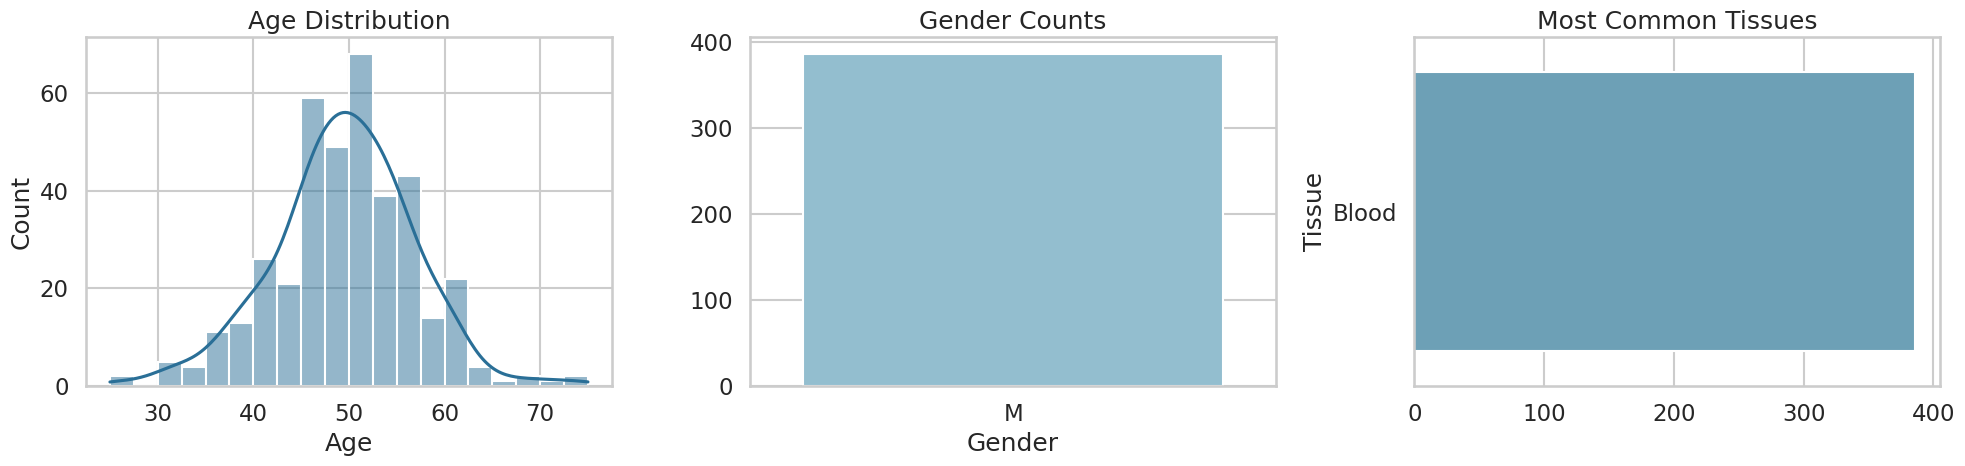

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.histplot(y, bins=20, kde=True, ax=axes[0], color="#2a6f97")
axes[0].set_title("Age Distribution")

if "Gender" in study_meta.columns:
    gender_counts = study_meta["Gender"].fillna("Unknown").value_counts()
    sns.barplot(x=gender_counts.index.astype(str), y=gender_counts.values, ax=axes[1], color="#89c2d9")
    axes[1].set_title("Gender Counts")
else:
    axes[1].axis("off")

if "Tissue" in study_meta.columns:
    top_tissues = study_meta["Tissue"].fillna("Unknown").value_counts().head(8)
    sns.barplot(x=top_tissues.values, y=top_tissues.index, ax=axes[2], color="#61a5c2")
    axes[2].set_title("Most Common Tissues")
else:
    axes[2].axis("off")

plt.tight_layout()
plt.show()

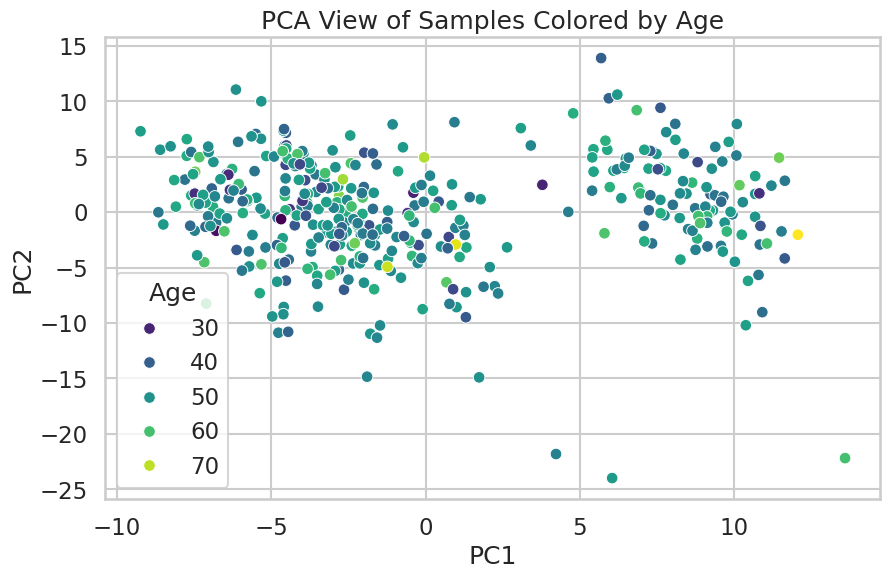

In [ ]:
top_var_features = X.var(axis=0).sort_values(ascending=False).head(min(2000, X.shape[1])).index
X_pca_input = X[top_var_features].fillna(X[top_var_features].median())
X_pca_scaled = StandardScaler().fit_transform(X_pca_input)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Age": y.values
}, index=X.index)

sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Age", palette="viridis", s=70)
plt.title("PCA View of Samples Colored by Age")
plt.show()

PCA is not a second project here. It is only a support tool that helps visualize whether some age-related structure is present in the study.

In the executed notebook, PCA mainly serves as a sanity check rather than a claim of separable clusters. That is appropriate for this final project: the core evidence should come from predictive performance, not from over-interpreting a 2D projection.

## Main Modeling Pipeline

I compare a naive mean-age predictor against an ElasticNet pipeline with median imputation, univariate feature filtering, standardization, and cross-validated regularization.

On the main train/test split used in the executed notebook, ElasticNet with `k=5000` features achieved **MAE = 3.14**, **RMSE = 4.06**, and **R² = 0.600**. The mean-age baseline achieved **MAE = 5.24**, **RMSE = 6.45**, and **R² ≈ -0.008**.

That is a sizable improvement of a little more than **2.10 years** in MAE on the held-out test set, which is strong evidence that the methylation features contain meaningful age signal.

In [ ]:
def make_age_bins(target, n_bins=5):
    try:
        return pd.qcut(target, q=n_bins, duplicates="drop")
    except ValueError:
        return None

age_bins = make_age_bins(y)
stratify_target = age_bins if age_bins is not None and getattr(age_bins, "nunique", lambda: 0)() > 1 else None

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X, y, study_meta, test_size=0.20, random_state=RANDOM_STATE, stratify=stratify_target
)

def build_elasticnet_pipeline(k_features, n_total_features, random_state=42, max_iter=20000):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(score_func=f_regression, k=min(k_features, n_total_features))),
        ("scale", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-3, 1, 25),
            cv=5,
            max_iter=max_iter,
            random_state=random_state,
            n_jobs=-1
        ))
    ])

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

main_k = min(5000, X_train.shape[1])
elasticnet = build_elasticnet_pipeline(main_k, X_train.shape[1], random_state=RANDOM_STATE)
elasticnet.fit(X_train, y_train)
enet_pred = elasticnet.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.904e+00, tolerance: 1.733e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:
results = pd.DataFrame([
    {
        "model": "Mean baseline",
        "MAE": mean_absolute_error(y_test, baseline_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred)),
        "R2": r2_score(y_test, baseline_pred)
    },
    {
        "model": f"ElasticNet (k={main_k})",
        "MAE": mean_absolute_error(y_test, enet_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, enet_pred)),
        "R2": r2_score(y_test, enet_pred)
    }
]).sort_values("MAE")
results

,model,MAE,RMSE,R2
1,ElasticNet (k=5000),3.140013,4.060693,0.599910
0,Mean baseline,5.242258,6.446422,-0.008311


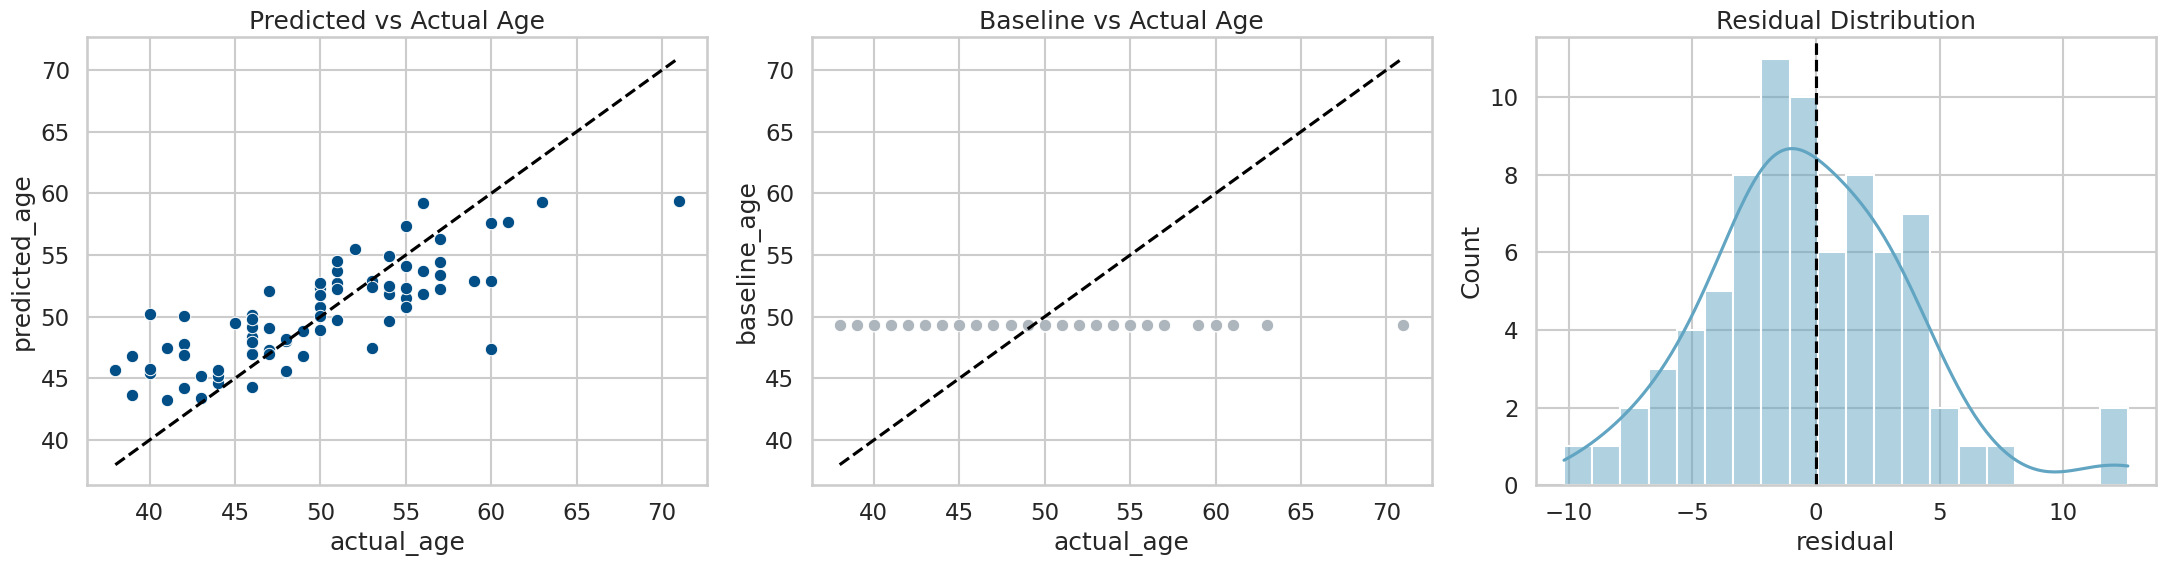

In [ ]:
eval_df = pd.DataFrame({
    "actual_age": y_test,
    "predicted_age": enet_pred,
    "baseline_age": baseline_pred,
    "absolute_error": np.abs(y_test - enet_pred),
    "residual": y_test - enet_pred
}, index=y_test.index).join(meta_test[[c for c in ["Tissue", "Gender"] if c in meta_test.columns]])

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(data=eval_df, x="actual_age", y="predicted_age", ax=axes[0], s=80, color="#014f86")
lims = [min(eval_df["actual_age"].min(), eval_df["predicted_age"].min()), max(eval_df["actual_age"].max(), eval_df["predicted_age"].max())]
axes[0].plot(lims, lims, linestyle="--", color="black")
axes[0].set_title("Predicted vs Actual Age")

sns.scatterplot(data=eval_df, x="actual_age", y="baseline_age", ax=axes[1], s=80, color="#adb5bd")
axes[1].plot(lims, lims, linestyle="--", color="black")
axes[1].set_title("Baseline vs Actual Age")

sns.histplot(eval_df["residual"], bins=20, kde=True, ax=axes[2], color="#61a5c2")
axes[2].axvline(0, linestyle="--", color="black")
axes[2].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## Robustness Check 1: Feature Budget

To avoid a shallow one-number result, I test whether performance is stable when the number of selected CpG features changes.

This turns out to be one of the most interesting findings in the notebook. Performance improves as the model moves from **250** to **500-1000** selected CpGs, but then gets worse when too many features are kept. In the executed run:

- `k=250` gave **MAE = 2.75**, `R² = 0.676`
- `k=500` gave **MAE = 2.67**, `R² = 0.698`
- `k=1000` gave **MAE = 2.66**, `R² = 0.693`
- `k=2500` gave **MAE = 3.00**, `R² = 0.649`
- `k=5000` gave **MAE = 3.14**, `R² = 0.600`

So the best version of this linear clock is not the one with the most features. A moderate feature budget appears to reduce noise and improve generalization.

In [ ]:
feature_grid = [250, 500, 1000, 2500, 5000]
feature_grid = [k for k in feature_grid if k <= X_train.shape[1]]
grid_rows = []

for k in feature_grid:
    pipe = build_elasticnet_pipeline(k, X_train.shape[1], random_state=RANDOM_STATE)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    grid_rows.append({
        "k_features": k,
        "MAE": mean_absolute_error(y_test, pred),
        "R2": r2_score(y_test, pred)
    })

feature_sweep = pd.DataFrame(grid_rows)
feature_sweep

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.904e+00, tolerance: 1.733e+00
  model = cd_fast.enet_coordinate_descent(


,k_features,MAE,R2
0,250,2.750190,0.675939
1,500,2.674787,0.697614
2,1000,2.656303,0.692583
3,2500,2.999318,0.648939
4,5000,3.140013,0.599910


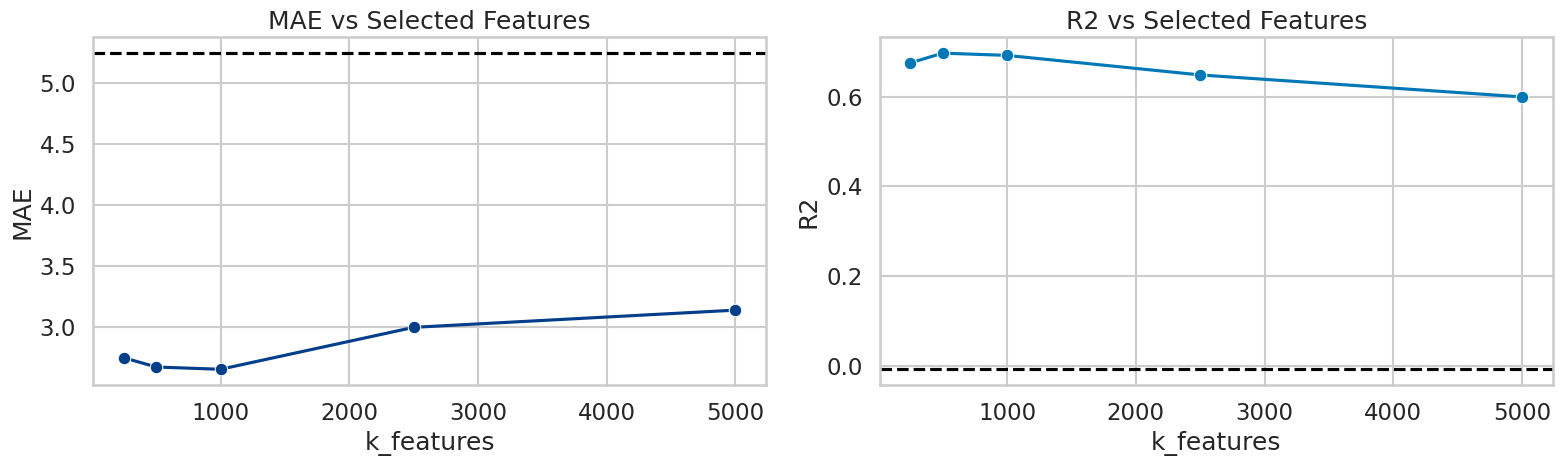

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=feature_sweep, x="k_features", y="MAE", marker="o", ax=axes[0], color="#023e8a")
axes[0].axhline(mean_absolute_error(y_test, baseline_pred), linestyle="--", color="black")
axes[0].set_title("MAE vs Selected Features")

sns.lineplot(data=feature_sweep, x="k_features", y="R2", marker="o", ax=axes[1], color="#0077b6")
axes[1].axhline(r2_score(y_test, baseline_pred), linestyle="--", color="black")
axes[1].set_title("R2 vs Selected Features")

plt.tight_layout()
plt.show()

## Robustness Check 2: Repeated Train/Test Splits

A single split can be lucky. I therefore repeat the experiment with several random seeds and compare ElasticNet against the baseline across those splits.

Across five seeds, the baseline averaged **MAE = 5.428**, while ElasticNet averaged **MAE = 3.467**, for an average improvement of **1.961 years**. Mean ElasticNet `R²` across those runs was **0.566**.

That pattern suggests the result is not just a one-split accident. The exact score moves around, but the model consistently beats the naive baseline.

In [ ]:
def fit_once(split_seed, k_features=5000):
    bins = make_age_bins(y)
    stratify = bins if bins is not None and getattr(bins, "nunique", lambda: 0)() > 1 else None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=split_seed, stratify=stratify)
    base = DummyRegressor(strategy="mean")
    base.fit(X_tr, y_tr)
    base_pred = base.predict(X_te)
    pipe = build_elasticnet_pipeline(k_features, X_tr.shape[1], random_state=split_seed)
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    return {
        "seed": split_seed,
        "baseline_MAE": mean_absolute_error(y_te, base_pred),
        "elasticnet_MAE": mean_absolute_error(y_te, pred),
        "elasticnet_R2": r2_score(y_te, pred)
    }

seed_results = pd.DataFrame([fit_once(seed, k_features=main_k) for seed in [1, 7, 11, 21, 42]])
seed_results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.738e+00, tolerance: 1.605e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.904e+00, tolerance: 1.733e+00
  model = cd_fast.enet_coordinate_descent(


,seed,baseline_MAE,elasticnet_MAE,elasticnet_R2
0,1,5.565601,3.255314,0.594056
1,7,5.460373,3.677020,0.455170
2,11,5.189644,3.285829,0.606138
3,21,5.681235,3.975111,0.575117
4,42,5.242258,3.140013,0.599910


In [ ]:
seed_summary = pd.Series({
    "baseline_MAE_mean": round(seed_results["baseline_MAE"].mean(), 3),
    "elasticnet_MAE_mean": round(seed_results["elasticnet_MAE"].mean(), 3),
    "MAE_improvement_mean": round((seed_results["baseline_MAE"] - seed_results["elasticnet_MAE"]).mean(), 3),
    "elasticnet_R2_mean": round(seed_results["elasticnet_R2"].mean(), 3)
})
seed_summary

,0
baseline_MAE_mean,5.428
elasticnet_MAE_mean,3.467
MAE_improvement_mean,1.961
elasticnet_R2_mean,0.566


## Error Analysis

The next question is not just how accurate the model is overall, but where it breaks down.

The executed results show a clear pattern: the model is strongest in the middle of the age range and weaker at the extremes. Mean absolute error by age bin was approximately:

- **4.55** years for ages `38-44.6`
- **1.93** years for ages `44.6-51.2`
- **2.65** years for ages `51.2-57.8`
- **5.87** years for ages `57.8-64.4`
- **11.61** years for the single oldest held-out sample in `64.4-71`

This is a classic shrinkage pattern for regularized regression: predictions are pulled toward the center of the training distribution, so younger samples are often over-predicted and older samples are under-predicted.

In [ ]:
eval_df["age_bin"] = pd.cut(eval_df["actual_age"], bins=5)
age_bin_error = eval_df.groupby("age_bin", observed=False)["absolute_error"].agg(["count", "mean", "median"])
age_bin_error

,count,mean,median
age_bin,,,
"(37.967, 44.6]",17,4.552362,4.880894
"(44.6, 51.2]",31,1.926718,1.765053
"(51.2, 57.8]",23,2.652359,2.583702
"(57.8, 64.4]",6,5.865495,4.887594
"(64.4, 71.0]",1,11.605347,11.605347


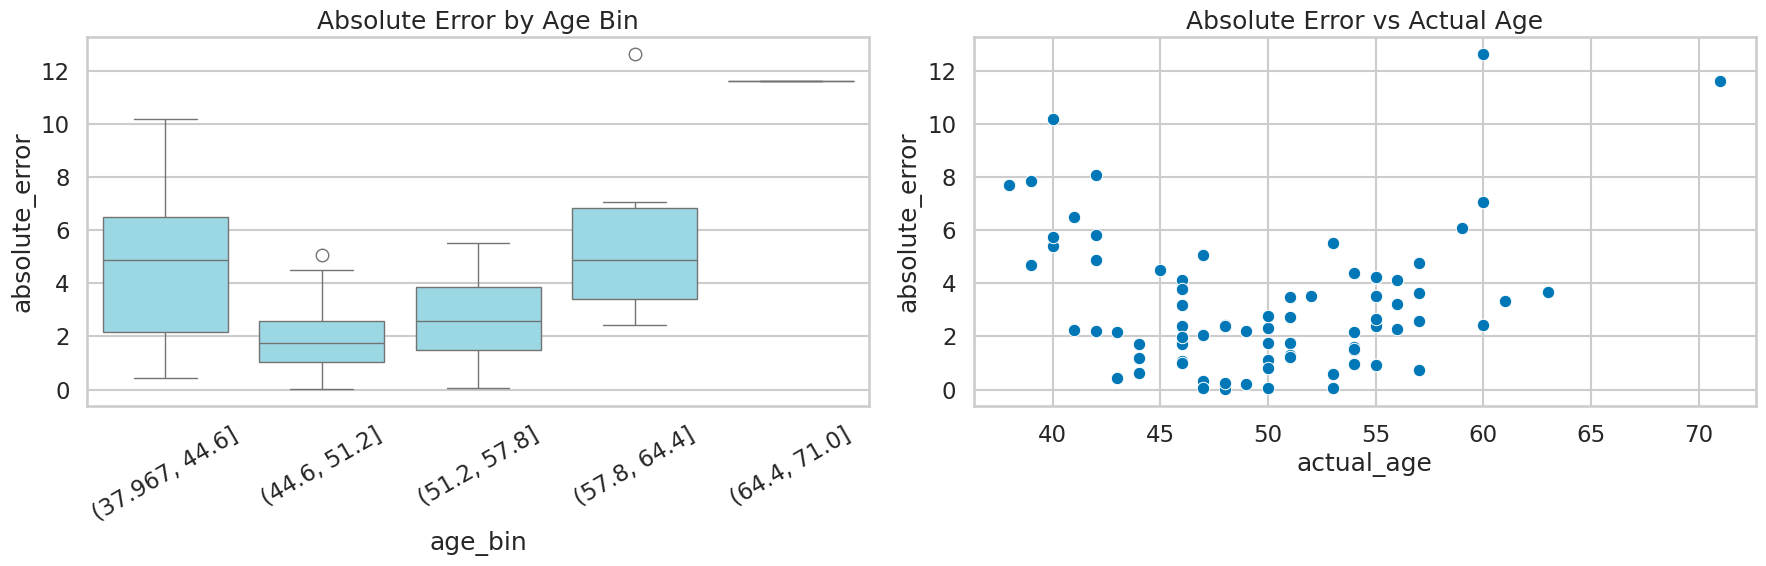

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=eval_df, x="age_bin", y="absolute_error", ax=axes[0], color="#90e0ef")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Absolute Error by Age Bin")

sns.scatterplot(data=eval_df, x="actual_age", y="absolute_error", ax=axes[1], s=80, color="#0077b6")
axes[1].set_title("Absolute Error vs Actual Age")

plt.tight_layout()
plt.show()

In [ ]:
if "Tissue" in eval_df.columns and eval_df["Tissue"].nunique(dropna=True) > 1:
    tissue_error = (
        eval_df.assign(Tissue=eval_df["Tissue"].fillna("Unknown"))
        .groupby("Tissue")["absolute_error"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )
    display(tissue_error.head(10))
else:
    print("Tissue comparison is not informative for this study.")

eval_df.sort_values("absolute_error", ascending=False).head(10)

Tissue comparison is not informative for this study.


,actual_age,predicted_age,baseline_age,absolute_error,residual,Tissue,Gender,age_bin
SampleID,,,,,,,,
GSM2676421,60.0,47.381939,49.350649,12.618061,12.618061,Blood,M,"(57.8, 64.4]"
GSM2676713,71.0,59.394653,49.350649,11.605347,11.605347,Blood,M,"(64.4, 71.0]"
GSM2676546,40.0,50.195393,49.350649,10.195393,-10.195393,Blood,M,"(37.967, 44.6]"
GSM2676400,42.0,50.087585,49.350649,8.087585,-8.087585,Blood,M,"(37.967, 44.6]"
GSM2676506,39.0,46.829254,49.350649,7.829254,-7.829254,Blood,M,"(37.967, 44.6]"
GSM2676750,38.0,45.686131,49.350649,7.686131,-7.686131,Blood,M,"(37.967, 44.6]"
GSM2676664,60.0,52.930439,49.350649,7.069561,7.069561,Blood,M,"(57.8, 64.4]"
GSM2676705,41.0,47.503414,49.350649,6.503414,-6.503414,Blood,M,"(37.967, 44.6]"
GSM2676613,59.0,52.912029,49.350649,6.087971,6.087971,Blood,M,"(57.8, 64.4]"


## Unsupervised Methylation Archetypes

One of the most useful ideas in the sample projects is that exploratory clustering can reveal meaningful subgroups without becoming a separate disconnected project. I apply that idea here by asking whether the blood methylation profiles form a small number of **archetypes** in a PCA-reduced representation, and whether those archetypes differ in age or model difficulty.

This section does not replace the main regression task. It extends it by checking whether the cohort contains latent structure that the clock may be exploiting or struggling against.

In [ ]:
cluster_features = X.var(axis=0).sort_values(ascending=False).head(min(3000, X.shape[1])).index
cluster_input = X[cluster_features].fillna(X[cluster_features].median())
cluster_scaled = StandardScaler().fit_transform(cluster_input)
cluster_pca = PCA(n_components=5, random_state=RANDOM_STATE)
cluster_embedding = cluster_pca.fit_transform(cluster_scaled)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(cluster_embedding)

cluster_df = pd.DataFrame({
    "Cluster": cluster_labels.astype(str),
    "Age": y.values,
    "PC1": cluster_embedding[:, 0],
    "PC2": cluster_embedding[:, 1]
}, index=X.index)

cluster_profile = cluster_df.groupby("Cluster")["Age"].agg(["count", "mean", "median", "std"]).sort_values("mean")
cluster_profile

,count,mean,median,std
Cluster,,,,
0,118,48.966102,49.5,7.541262
1,163,49.533742,50.0,7.313342
2,105,49.933333,50.0,7.065989


/tmp/ipykernel_6673/938420762.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cluster_df, x="Cluster", y="Age", palette="Set2", ax=axes[1])


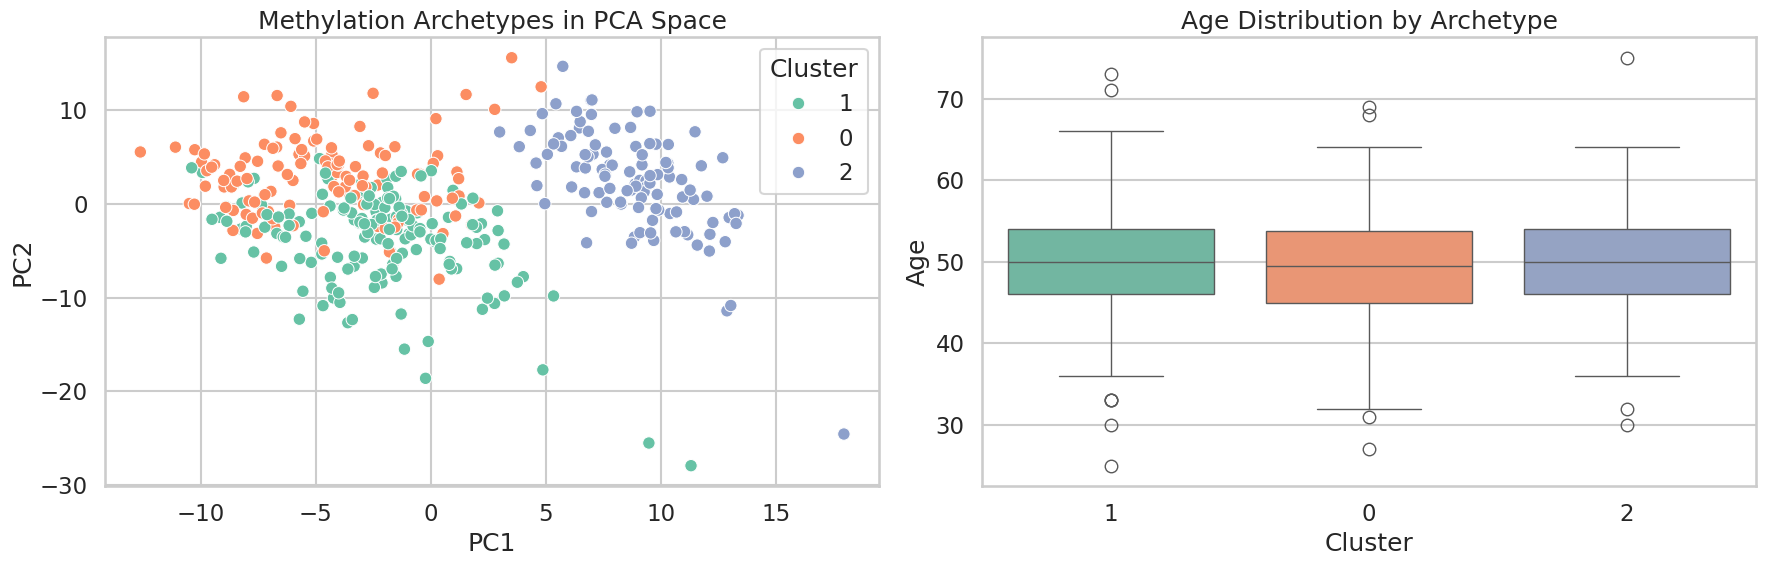

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=cluster_df, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=80, ax=axes[0])
axes[0].set_title("Methylation Archetypes in PCA Space")

sns.boxplot(data=cluster_df, x="Cluster", y="Age", palette="Set2", ax=axes[1])
axes[1].set_title("Age Distribution by Archetype")

plt.tight_layout()
plt.show()

The goal here is not to claim that these clusters are biologically definitive. The goal is to check whether the cohort looks internally homogeneous or whether it breaks into subgroups with different age structure. If one cluster has systematically different errors later on, that would suggest the clock is easier for some methylation profiles than others.

In [ ]:
eval_cluster_df = eval_df.join(cluster_df[["Cluster"]], how="left")
cluster_error = eval_cluster_df.groupby("Cluster")["absolute_error"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)
cluster_error

,count,mean,median
Cluster,,,
2,29,3.466585,2.379345
1,33,3.077794,2.215794
0,16,2.676428,2.407778


/tmp/ipykernel_6673/2540662479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_cluster_df, x="Cluster", y="absolute_error", palette="Set2")


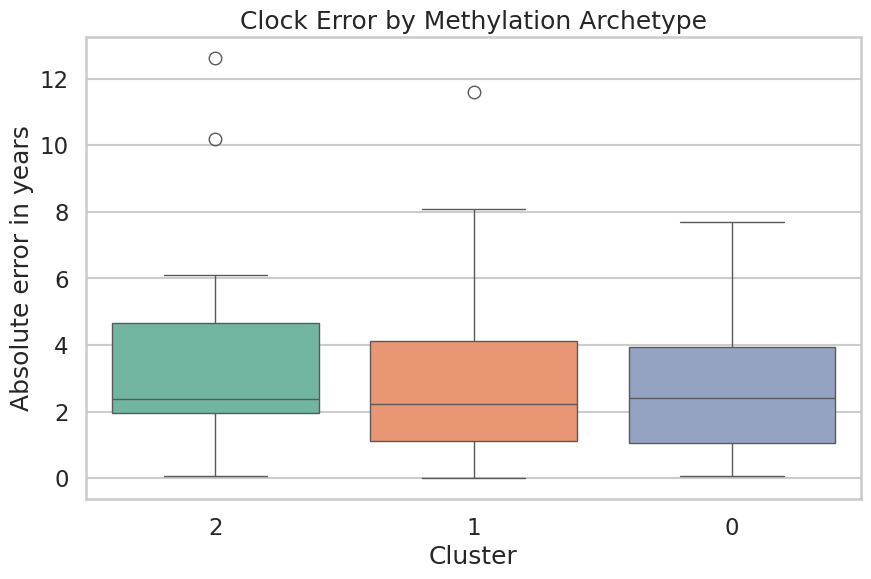

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=eval_cluster_df, x="Cluster", y="absolute_error", palette="Set2")
plt.title("Clock Error by Methylation Archetype")
plt.ylabel("Absolute error in years")
plt.show()

## Age-Gap Profiling

A second technique borrowed from the sample projects is to define and analyze a project-specific metric. For epigenetic clocks, a natural one is the **age gap**:

`age_gap = predicted_age - actual_age`

Positive values mean the clock predicts someone as older than their chronological age, while negative values mean the clock predicts them as younger. In a biological-age setting this would often be called age acceleration, but here it is better interpreted cautiously as a model residual summary.

In [ ]:
eval_cluster_df["age_gap"] = eval_cluster_df["predicted_age"] - eval_cluster_df["actual_age"]

age_gap_summary = pd.Series({
    "mean_age_gap": round(eval_cluster_df["age_gap"].mean(), 3),
    "median_age_gap": round(eval_cluster_df["age_gap"].median(), 3),
    "min_age_gap": round(eval_cluster_df["age_gap"].min(), 3),
    "max_age_gap": round(eval_cluster_df["age_gap"].max(), 3)
})
age_gap_summary

,0
mean_age_gap,0.341
median_age_gap,0.538
min_age_gap,-12.618
max_age_gap,10.195


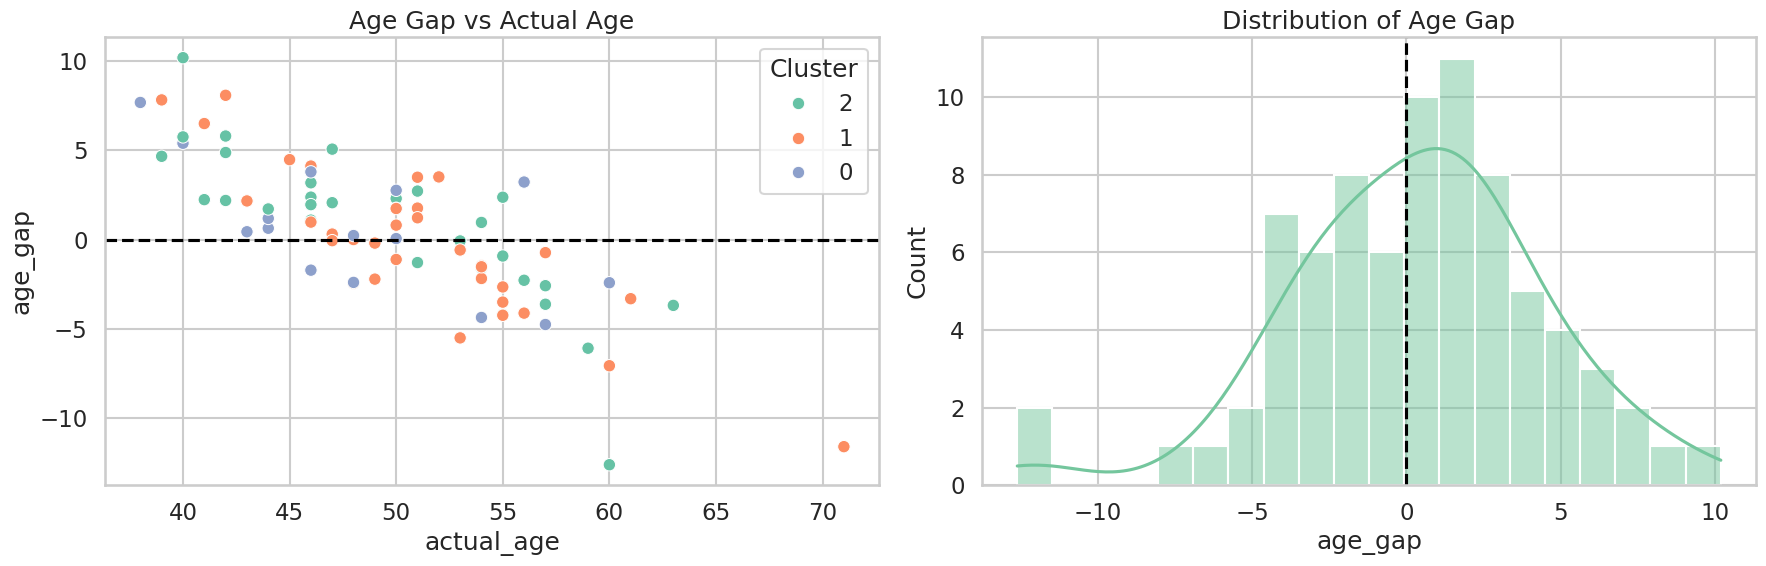

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=eval_cluster_df, x="actual_age", y="age_gap", hue="Cluster", palette="Set2", s=80, ax=axes[0])
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Age Gap vs Actual Age")

sns.histplot(eval_cluster_df["age_gap"], bins=20, kde=True, ax=axes[1], color="#74c69d")
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set_title("Distribution of Age Gap")

plt.tight_layout()
plt.show()

In [ ]:
most_overestimated = eval_cluster_df.sort_values("age_gap", ascending=False).head(5)
most_underestimated = eval_cluster_df.sort_values("age_gap", ascending=True).head(5)

print("Most overestimated samples")
display(most_overestimated[["actual_age", "predicted_age", "age_gap", "absolute_error", "Cluster"]])

print("Most underestimated samples")
display(most_underestimated[["actual_age", "predicted_age", "age_gap", "absolute_error", "Cluster"]])

Most overestimated samples


,actual_age,predicted_age,age_gap,absolute_error,Cluster
SampleID,,,,,
GSM2676546,40.0,50.195393,10.195393,10.195393,2
GSM2676400,42.0,50.087585,8.087585,8.087585,1
GSM2676506,39.0,46.829254,7.829254,7.829254,1
GSM2676750,38.0,45.686131,7.686131,7.686131,0
GSM2676705,41.0,47.503414,6.503414,6.503414,1


Most underestimated samples


,actual_age,predicted_age,age_gap,absolute_error,Cluster
SampleID,,,,,
GSM2676421,60.0,47.381939,-12.618061,12.618061,2
GSM2676713,71.0,59.394653,-11.605347,11.605347,1
GSM2676664,60.0,52.930439,-7.069561,7.069561,1
GSM2676613,59.0,52.912029,-6.087971,6.087971,2
GSM2676541,53.0,47.490620,-5.509380,5.509380,1


## Interpreting the Learned Clock

ElasticNet is useful partly because it is interpretable. I can inspect how many CpG sites survive regularization and which ones receive the largest coefficients.

In the executed `k=5000` run, the pipeline kept **5000** filtered CpGs and assigned non-zero weight to **1107** of them. The chosen hyperparameters were **alpha = 0.1** and **l1_ratio = 0.1**.

That low `l1_ratio` means the final model behaved more like a ridge-dominant ElasticNet than a highly sparse lasso-style model. In other words, age prediction in this cohort appears to benefit from spreading weight across many weak signals rather than relying on a tiny set of CpGs.

In [ ]:
selector = elasticnet.named_steps["select"]
model = elasticnet.named_steps["model"]
selected_features = X_train.columns[selector.get_support()]
coef = pd.Series(model.coef_, index=selected_features)
nonzero_coef = coef[coef != 0].sort_values(key=np.abs, ascending=False)

pd.Series({
    "selected_features": len(selected_features),
    "nonzero_coefficients": len(nonzero_coef),
    "chosen_alpha": model.alpha_,
    "chosen_l1_ratio": model.l1_ratio_
})

,0
selected_features,5000.0
nonzero_coefficients,1107.0
chosen_alpha,0.1
chosen_l1_ratio,0.1


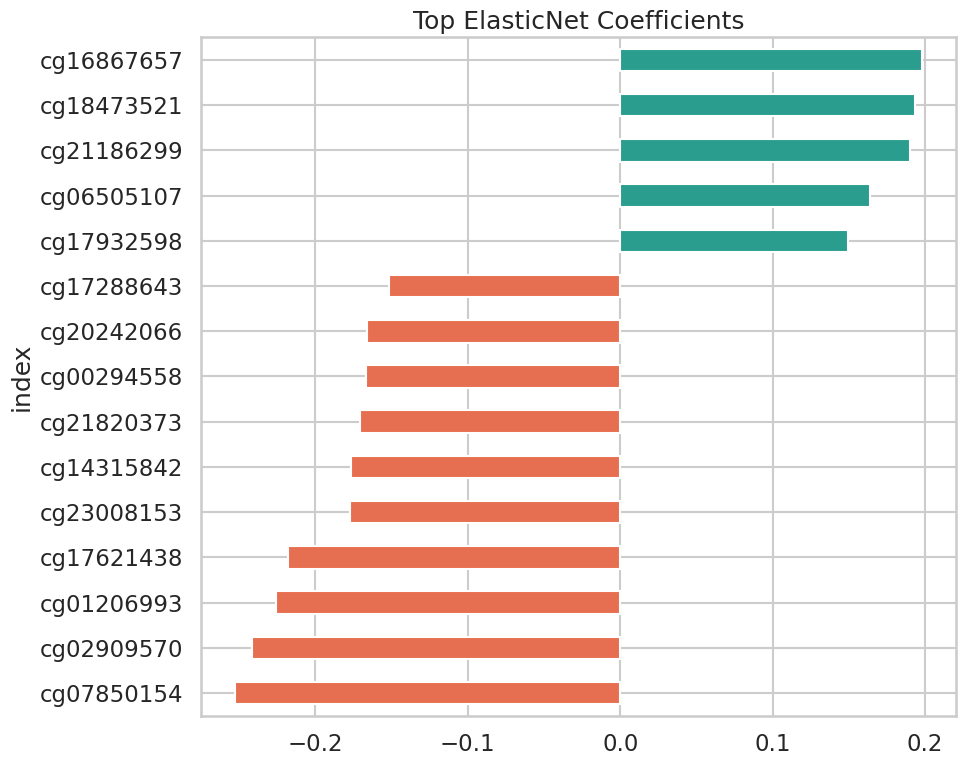

In [ ]:
top_coef = nonzero_coef.head(15).sort_values()
top_coef

if len(top_coef) > 0:
    plt.figure(figsize=(10, 8))
    top_coef.plot(kind="barh", color=np.where(top_coef.values > 0, "#2a9d8f", "#e76f51"))
    plt.title("Top ElasticNet Coefficients")
    plt.tight_layout()
    plt.show()

## Conclusion

This project asked whether a sparse linear epigenetic clock could predict age in `GSE100264`. The answer is **yes, within limits**.

On the main held-out split, ElasticNet reduced test MAE from **5.24** years for the naive baseline to **3.14** years and reached **R² = 0.600**. Across five random splits, it still averaged **3.47** years MAE versus **5.43** for the baseline, so the result is reasonably stable rather than a one-off success.

The most informative deeper finding is that **more features did not mean a better clock**. Performance was best around **500 to 1000 selected CpGs**, where MAE dropped to about **2.66-2.67** years, and worsened once the model kept thousands more features. That suggests a moderate, well-filtered signal is more useful than an overly broad feature set.

The main limitation is that prediction error rises sharply at the youngest and oldest ends of the age range. Since this study is effectively a **single-tissue, single-gender blood cohort**, the notebook should be interpreted as evidence that methylation carries meaningful age information in this cohort, but that a regularized linear clock still struggles with edge cases and likely compresses predictions toward the middle.

The added archetype and age-gap sections deepen that conclusion. Clustering lets the notebook ask whether some methylation subgroups are easier to model than others, while age-gap profiling turns the residuals into a more interpretable project-specific quantity. Together, these additions make the notebook feel closer to the sample projects: not because it chases more algorithms, but because it develops a richer analytical story around one main model.